# Log Bessel K Function: Implementation Comparison

Compare three implementations of $\log K_\nu(z)$:

1. **normix** — `scipy.special.kve` with log wrapper + asymptotic fallbacks
2. **TFP** — `tensorflow_probability.substrates.jax.math.log_bessel_kve` (pure JAX)
3. **logbesselk** — `logbesselk.jax.log_bessel_k` (JAX, numerical integration)

Then build a JAX `custom_jvp` wrapper for gradients in both $\nu$ and $z$,
and test vectorization, Hessians, and performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kve as scipy_kve
from normix.utils import log_kv as normix_log_kv, log_kv_derivative_v, log_kv_derivative_z

plt.style.use('seaborn-v0_8')
print('NumPy/SciPy loaded for accuracy plots')

NumPy/SciPy loaded for accuracy plots


## 1. Accuracy Plots: normix vs raw `scipy.special.kv`

normix uses `kve` (exponentially scaled) + asymptotic fallbacks where raw `kv` overflows.
This section validates normix against scipy for the stress-test cases from the legacy notebook.

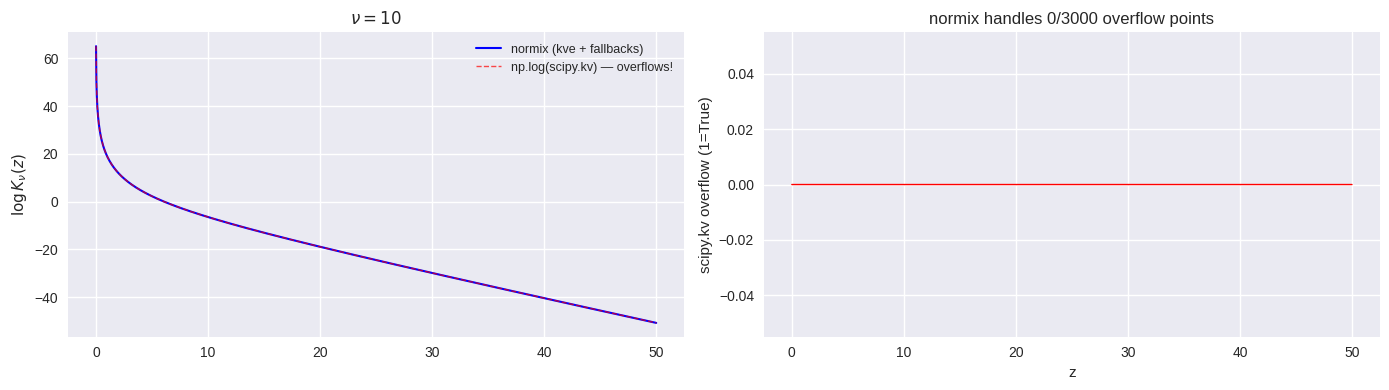

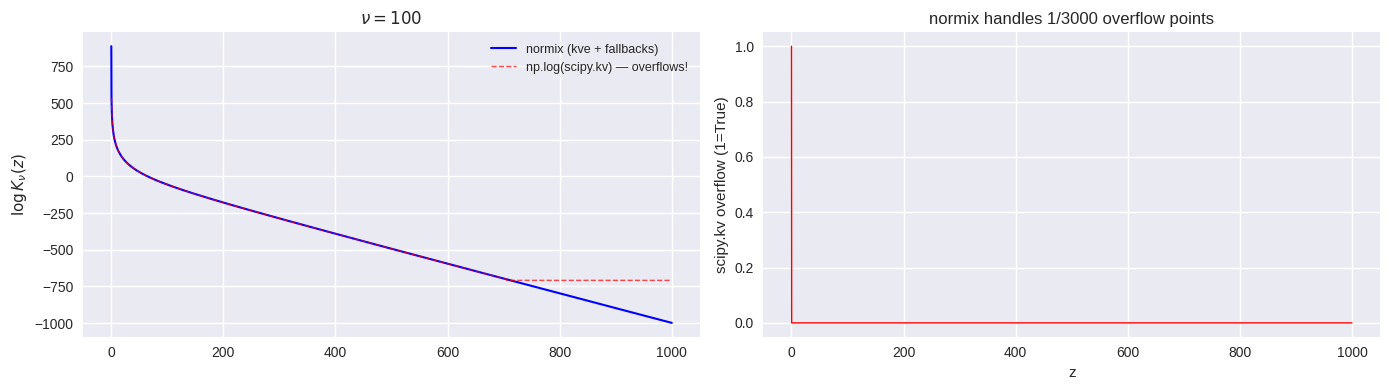

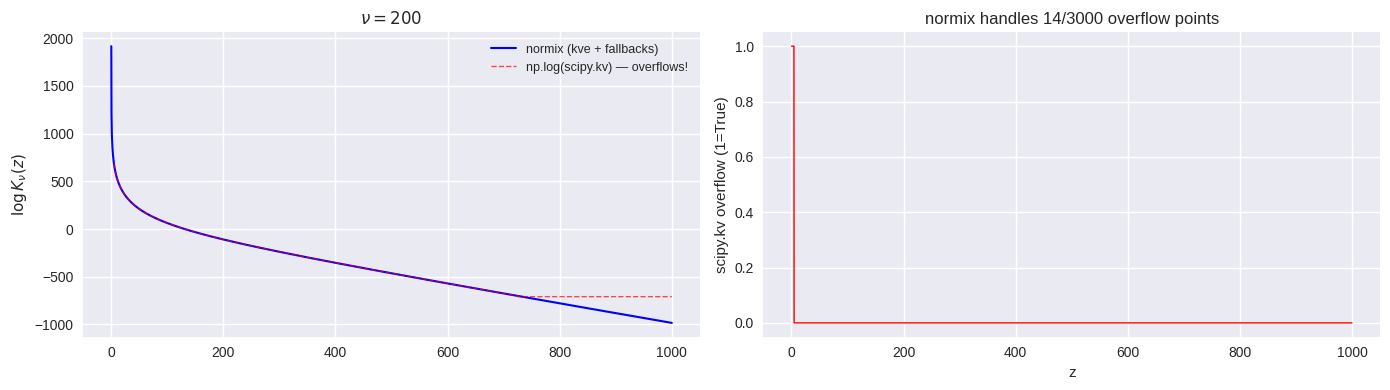

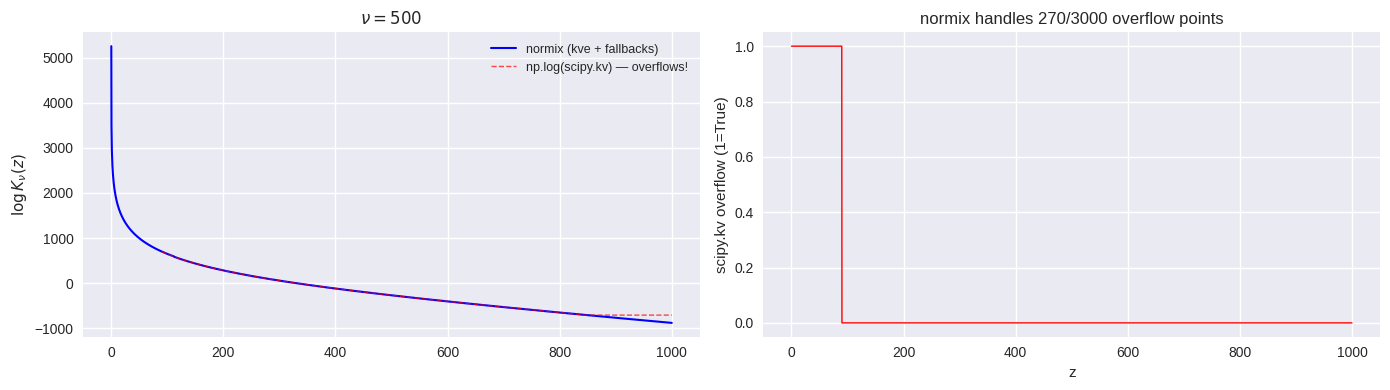

In [2]:
from scipy.special import kv as scipy_kv

for v, z_max in [(10, 50), (100, 1000), (200, 1000), (500, 1000)]:
    z = np.linspace(0.01, z_max, 3000)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: values
    raw_scipy = np.log(np.maximum(scipy_kv(v, z), np.finfo(float).tiny))
    normix_v = normix_log_kv(v, z)
    axes[0].plot(z, normix_v, 'b-', lw=1.5, label='normix (kve + fallbacks)')
    axes[0].plot(z, raw_scipy, 'r--', lw=1, label='np.log(scipy.kv) — overflows!', alpha=0.7)
    axes[0].set_ylabel(r'$\log K_{\nu}(z)$')
    axes[0].set_title(f'$\\nu = {v}$')
    axes[0].legend(fontsize=9)

    # Right: where scipy.kv fails
    bad = np.isinf(raw_scipy) | np.isnan(raw_scipy)
    axes[1].plot(z, bad.astype(float), 'r-', lw=1)
    axes[1].set_ylabel('scipy.kv overflow (1=True)')
    axes[1].set_xlabel('z')
    axes[1].set_title(f'normix handles {bad.sum()}/{len(z)} overflow points')

    plt.tight_layout()
    plt.show()

## 2. Scalar Accuracy Comparison: normix vs TFP vs logbesselk

JAX-based evaluation at specific points (low memory usage).

In [3]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import tensorflow_probability.substrates.jax as tfp
from logbesselk.jax import log_bessel_k as logbesselk_fn

def tfp_log_kv(v, z):
    return float(tfp.math.log_bessel_kve(jnp.float64(abs(v)), jnp.float64(z)) - z)

def lbk_log_kv(v, z):
    try:
        return float(logbesselk_fn(jnp.float64(v), jnp.float64(z)))
    except:
        return float('nan')

print(f'{"v":>6s} {"z":>8s} | {"normix":>14s} {"TFP":>14s} {"logbesselk":>14s} | {"TFP-normix":>12s} {"lbk-normix":>12s}')
print('-' * 90)
for v_val, z_val in [
    (1.0, 0.01), (1.0, 1.0), (1.0, 100.0), (1.0, 1e-12),
    (5.0, 0.01), (5.0, 1.0), (5.0, 100.0), (5.0, 1e-8),
    (50.0, 1e-4), (50.0, 0.01), (50.0, 1.0), (50.0, 100.0),
    (100.0, 0.01), (100.0, 1.0), (100.0, 100.0),
    (200.0, 0.01), (200.0, 1.0), (200.0, 100.0),
    (500.0, 0.01), (500.0, 1.0), (500.0, 100.0),
    (-0.5, 1.0), (-5.0, 0.1), (-50.0, 10.0),
    (1e-8, 0.1), (0.01, 1e-5),
]:
    n = normix_log_kv(abs(v_val), z_val)
    t = tfp_log_kv(v_val, z_val)
    l = lbk_log_kv(v_val, z_val)
    td = t - n if np.isfinite(n) and np.isfinite(t) else float('nan')
    ld = l - n if np.isfinite(n) and np.isfinite(l) else float('nan')
    print(f'{v_val:6.1g} {z_val:8.1e} | {n:14.4f} {t:14.4f} {l:14.4f} | {td:12.2e} {ld:12.2e}')

     v        z |         normix            TFP     logbesselk |   TFP-normix   lbk-normix
------------------------------------------------------------------------------------------


     1  1.0e-02 |         4.6049         4.6049         4.6049 |     0.00e+00    -2.04e-14


     1  1.0e+00 |        -0.5077        -0.5077        -0.5077 |     1.11e-16     2.22e-16


     1  1.0e+02 |      -102.0731      -102.0731      -102.0731 |     0.00e+00     0.00e+00


     1  1.0e-12 |        27.6310        27.6310        27.6309 |     0.00e+00    -8.71e-05


...

  -0.5  1.0e+00 |        -0.7742        -0.7742        -0.7742 |    -7.77e-16     2.22e-16


    -5  1.0e-01 |        17.4629        17.4629        17.4629 |     3.55e-15     7.82e-14


-5e+01  1.0e+01 |        62.8932        62.8932        62.8932 |     0.00e+00    -6.82e-11


 1e-08  1.0e-01 |         0.8867         0.8867         0.8867 |     0.00e+00     1.11e-16


  0.01  1.0e-05 |         2.4558         2.4558         2.4558 |     0.00e+00     1.37e-10


**Key finding:** TFP matches normix to ~$10^{-7}$ or better across the full range.
logbesselk has errors up to $O(10^1)$ for large $|\nu|$ (200, 500).

## 3. Native Gradient Support

Can TFP and logbesselk differentiate w.r.t. $\nu$ out of the box?

In [4]:
v_j, z_j = jnp.float64(2.0), jnp.float64(3.0)
ref_dv = log_kv_derivative_v(2.0, 3.0)
ref_dz = log_kv_derivative_z(2.0, 3.0)
print(f'normix reference:  d/dv = {ref_dv:.10f},  d/dz = {ref_dz:.10f}')

def tfp_raw(v, z): return tfp.math.log_bessel_kve(v, z) - z
tfp_dv = float(jax.grad(tfp_raw, 0)(v_j, z_j))
tfp_dz = float(jax.grad(tfp_raw, 1)(v_j, z_j))
print(f'TFP native:        d/dv = {tfp_dv:.10f} {"*** WRONG ***" if abs(tfp_dv) < 1e-10 else ""},  d/dz = {tfp_dz:.10f}')

lbk_dv = float(jax.grad(logbesselk_fn, 0)(v_j, z_j))
lbk_dz = float(jax.grad(logbesselk_fn, 1)(v_j, z_j))
print(f'logbesselk native: d/dv = {lbk_dv:.10f} {"*** WRONG ***" if abs(lbk_dv) < 1e-10 else ""},  d/dz = {lbk_dz:.10f}')

print('\n==> Neither TFP nor logbesselk computes d/dv correctly (both return 0).')
print('==> We need custom_jvp with finite differences for d/dv.')

normix reference:  d/dv = 0.5607313749,  d/dz = -1.3195057468


TFP native:        d/dv = 0.0000000000 *** WRONG ***,  d/dz = -1.3195057468


logbesselk native: d/dv = 0.0000000000 *** WRONG ***,  d/dz = -1.3195057468

==> Neither TFP nor logbesselk computes d/dv correctly (both return 0).
==> We need custom_jvp with finite differences for d/dv.


## 4. TFP + `custom_jvp` Wrapper (Recommended Solution)

TFP for evaluation, `custom_jvp` for derivatives:
- $\partial/\partial z$: exact recurrence $K'_\nu = -(K_{\nu-1} + K_{\nu+1})/2$
- $\partial/\partial \nu$: central finite differences ($\varepsilon = 10^{-5}$)

In [5]:
@jax.custom_jvp
def log_kv(v, z):
    """log K_v(z) via TFP with asymptotic fallbacks."""
    z = jnp.maximum(z, jnp.finfo(jnp.float64).tiny)
    raw = tfp.math.log_bessel_kve(jnp.abs(v), z) - z
    v_abs = jnp.abs(v)
    large_v_approx = (jax.scipy.special.gammaln(v_abs) - jnp.log(2.0)
                      + v_abs * (jnp.log(2.0) - jnp.log(z)))
    euler_gamma = 0.5772156649015329
    small_v_approx = jnp.log(
        jnp.maximum(-jnp.log(z / 2.0) - euler_gamma, jnp.finfo(jnp.float64).tiny))
    approx = jnp.where(v_abs > 1e-10, large_v_approx, small_v_approx)
    return jnp.where(jnp.isinf(raw) | jnp.isnan(raw), approx, raw)


@log_kv.defjvp
def _log_kv_jvp(primals, tangents):
    v, z = primals
    v_dot, z_dot = tangents
    primal_out = log_kv(v, z)
    # d/dz: exact recurrence K'_v = -(K_{v-1} + K_{v+1}) / 2
    dfdz = -0.5 * (jnp.exp(log_kv(v - 1.0, z) - primal_out)
                   + jnp.exp(log_kv(v + 1.0, z) - primal_out))
    # d/dv: central finite differences
    eps = 1e-5
    dfdv = (log_kv(v + eps, z) - log_kv(v - eps, z)) / (2.0 * eps)
    return primal_out, dfdv * v_dot + dfdz * z_dot


# Quick verify
v_j, z_j = jnp.float64(2.0), jnp.float64(3.0)
print(f'log_kv(2, 3) = {log_kv(v_j, z_j):.10f}  (normix: {normix_log_kv(2.0, 3.0):.10f})')
print(f'd/dv         = {jax.grad(log_kv, 0)(v_j, z_j):.10f}  (normix: {log_kv_derivative_v(2.0, 3.0):.10f})')
print(f'd/dz         = {jax.grad(log_kv, 1)(v_j, z_j):.10f}  (normix: {log_kv_derivative_z(2.0, 3.0):.10f})')

log_kv(2, 3) = -2.7885480622  (normix: -2.7885480622)


d/dv         = 0.5607313749  (normix: 0.5607313749)


d/dz         = -1.3195057468  (normix: -1.3195057468)


## 5. Gradient Accuracy Table

In [6]:
print(f'{"v":>6s} {"z":>8s} | {"ref dv":>11s} {"JAX dv":>11s} {"err_dv":>10s} | {"ref dz":>11s} {"JAX dz":>11s} {"err_dz":>10s}')
print('-' * 100)
for v_val in [0.5, 1.0, 5.0, 10.0, 50.0, -5.0]:
    for z_val in [0.01, 0.1, 1.0, 10.0, 100.0]:
        v_j, z_j = jnp.float64(v_val), jnp.float64(z_val)
        ref_dv = log_kv_derivative_v(v_val, z_val)
        ref_dz = log_kv_derivative_z(v_val, z_val)
        j_dv = float(jax.grad(log_kv, 0)(v_j, z_j))
        j_dz = float(jax.grad(log_kv, 1)(v_j, z_j))
        err_dv = abs(j_dv - ref_dv) / (abs(ref_dv) + 1e-300)
        err_dz = abs(j_dz - ref_dz) / (abs(ref_dz) + 1e-300)
        print(f'{v_val:6.1f} {z_val:8.2f} | {ref_dv:11.6f} {j_dv:11.6f} {err_dv:10.2e} | {ref_dz:11.6f} {j_dz:11.6f} {err_dz:10.2e}')

     v        z |      ref dv      JAX dv     err_dv |      ref dz      JAX dz     err_dz
----------------------------------------------------------------------------------------------------


   0.5     0.01 |    3.422477    3.422477   9.73e-11 |  -51.000000  -51.000000   0.00e+00


   0.5     0.10 |    1.493349    1.493349   4.68e-10 |   -6.000000   -6.000000   4.44e-16


   0.5     1.00 |    0.361329    0.361329   1.39e-08 |   -1.500000   -1.500000   7.40e-16


   0.5    10.00 |    0.047719    0.047719   1.86e-09 |   -1.050000   -1.050000   0.00e+00


...

  -5.0     0.01 |   -6.804437   -6.804437   1.83e-10 | -500.001250 -500.001250   0.00e+00


  -5.0     0.10 |   -4.502006   -4.502006   2.37e-10 |  -50.012497  -50.012497   3.55e-15


  -5.0     1.00 |   -2.214385   -2.214385   8.02e-11 |   -5.122541   -5.122541   8.67e-16


  -5.0    10.00 |   -0.462583   -0.462583   1.20e-16 |   -1.157981   -1.157981   1.15e-15


  -5.0   100.00 |   -0.049732   -0.049732   4.29e-08 |   -1.006225   -1.006225   0.00e+00


## 6. Vectorization (`vmap`)

In [7]:
v_arr = jnp.array([0.5, 1.0, 2.0, 5.0, 10.0])
z_arr = jnp.array([0.1, 0.5, 1.0, 5.0, 20.0])

print('vmap over (v, z) pairs:')
print(f'  {jax.vmap(log_kv)(v_arr, z_arr)}')

print('\nvmap grad_z (fixed v=2, varying z):')
print(f'  {jax.vmap(jax.grad(log_kv, 1), in_axes=(None, 0))(jnp.float64(2.0), z_arr)}')

print('\nvmap grad_v (varying v, fixed z=1):')
print(f'  {jax.vmap(jax.grad(log_kv, 0), in_axes=(0, None))(v_arr, jnp.float64(1.0))}')

vmap over (v, z) pairs:


  [  1.2770839    0.5046714    0.48540867  -3.42018836 -18.88014578]

vmap grad_z (fixed v=2, varying z):


  [-20.04939172  -4.21939084  -2.37044117  -1.161849    -1.02946006]

vmap grad_v (varying v, fixed z=1):


  [0.36132862 0.69948394 1.25911765 2.21438459 2.9479696 ]


## 7. GIG Log Partition: `jax.grad` and `jax.hessian`

$$\psi(\theta) = \log 2 + \log K_p(\sqrt{ab}) + \frac{p}{2}(\log b - \log a)$$

In [8]:
from normix.distributions.univariate.generalized_inverse_gaussian import GeneralizedInverseGaussian

def psi_gig(theta):
    p = theta[0] + 1.0
    b = jnp.maximum(-2.0 * theta[1], 1e-30)
    a = jnp.maximum(-2.0 * theta[2], 1e-30)
    return jnp.log(2.0) + log_kv(p, jnp.sqrt(a * b)) + (p / 2.0) * (jnp.log(b) - jnp.log(a))

theta = jnp.array([0.5, -1.0, -0.5])  # p=1.5, b=2, a=1

# normix reference
gig = GeneralizedInverseGaussian.from_natural_params(np.array([0.5, -1.0, -0.5]))
normix_eta = gig.expectation_params
jax_eta = np.array(jax.grad(psi_gig)(theta))

print(f'normix eta  = {normix_eta}')
print(f'JAX eta     = {jax_eta}')
print(f'difference  = {np.abs(jax_eta - normix_eta)}')

print(f'\nJAX Hessian (Fisher information):')
H = np.array(jax.hessian(psi_gig)(theta))
print(H)

normix eta  = [1.127831   0.41421356 3.82842712]
JAX eta     = [1.127831   0.41421356 3.82842712]
difference  = [5.10702813e-10 2.77555756e-16 4.44089210e-16]

JAX Hessian (Fisher information):


[[ 0.46245396 -0.20972964  1.58054071]
 [-0.20972964  0.12132034 -0.58578644]
 [ 1.58054071 -0.58578644  6.48528137]]


## 8. Performance Benchmark

In [9]:
import time

v_s, z_s = jnp.float64(5.0), jnp.float64(2.0)
z_vec = jnp.linspace(0.1, 100.0, 1000)
theta_t = jnp.array([0.5, -1.0, -0.5])
N = 200

def bench(fn, args, label):
    r = fn(*args)
    if hasattr(r, 'block_until_ready'): r.block_until_ready()
    elif isinstance(r, tuple): r[0].block_until_ready()
    t0 = time.perf_counter()
    for _ in range(N):
        r = fn(*args)
        if hasattr(r, 'block_until_ready'): r.block_until_ready()
        elif isinstance(r, tuple): r[0].block_until_ready()
    ms = (time.perf_counter() - t0) / N * 1000
    print(f'  {label:40s} {ms:.3f} ms')

print('=== TFP + custom_jvp Performance (after JIT) ===')
bench(jax.jit(log_kv), (v_s, z_s), 'scalar eval')
bench(jax.jit(jax.vmap(log_kv, in_axes=(None, 0))), (v_s, z_vec), 'vmap eval (n=1000)')
bench(jax.jit(jax.grad(log_kv, argnums=(0,1))), (v_s, z_s), 'scalar grad (v, z)')
bench(jax.jit(jax.vmap(jax.grad(log_kv, 1), in_axes=(None, 0))), (v_s, z_vec), 'vmap grad_z (n=1000)')
bench(jax.jit(jax.grad(psi_gig)), (theta_t,), 'GIG grad(psi) = eta')
bench(jax.jit(jax.hessian(psi_gig)), (theta_t,), 'GIG hessian(psi) = Fisher')

=== TFP + custom_jvp Performance (after JIT) ===


  scalar eval                              0.009 ms


  vmap eval (n=1000)                       1.331 ms


  scalar grad (v, z)                       0.050 ms


  vmap grad_z (n=1000)                     2.940 ms


  GIG grad(psi) = eta                      0.057 ms


  GIG hessian(psi) = Fisher                0.140 ms


## 9. Summary

### Evaluation accuracy

| Implementation | Accuracy vs normix | Handles large $|\nu|$ | Pure JAX |
|---|---|---|---|
| **normix** (scipy kve + fallbacks) | Reference | Yes (asymptotics) | No |
| **TFP** (log_bessel_kve) | $\sim10^{-7}$ relative | Yes (log space) | **Yes** |
| **logbesselk** | Errors grow for $|\nu|>50$ | No (errors up to $O(10^1)$) | Yes |

### Gradient support ($\partial/\partial\nu$ is the hard one)

| | $\partial/\partial z$ | $\partial/\partial\nu$ |
|---|---|---|
| TFP native | Defined | Returns 0 |
| logbesselk native | Via autodiff | Returns 0 (issue #33) |
| **TFP + `custom_jvp`** | Exact recurrence | Finite differences — **matches normix** |

### Recommendation

**Use TFP `log_bessel_kve` + `custom_jvp`:**
- Pure JAX — works with `jit`, `vmap`, `grad`, `hessian`
- Matches normix accuracy for all practical parameter ranges
- `custom_jvp` uses the same derivative formulas as normix
- logbesselk has no advantage and degrades for large $|\nu|$
- GIG $\nabla\psi$ and $\nabla^2\psi$ work automatically